<a href="https://colab.research.google.com/github/Geovanasoliveira/dbt-duckdb/blob/main/Pipeline_DBT_%2B_DuckDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1️⃣ Instalar dependências

In [1]:
%%capture
!pip install dbt-core dbt-duckdb duckdb pandas seaborn

## 2️⃣ Autenticar no Google Drive e listar CSVs

In [2]:
from google.colab import auth, drive
auth.authenticate_user()
drive.mount('/content/drive')

from googleapiclient.discovery import build
drive_service = build('drive', 'v3')

FOLDER_ID = '1Ugy7tCtaoKa0_w0JANOoZLlA0bKNMhzW'
results = drive_service.files().list(
    q=f"'{FOLDER_ID}' in parents and mimeType='text/csv'",
    fields='files(id, name)'
).execute()
files = results.get('files', [])
print(f'✅ {len(files)} CSVs encontrados:')
for f in sorted(files, key=lambda x: x['name']):
    print(f"   - {f['name']}")

Mounted at /content/drive


✅ 14 CSVs encontrados:
   - categories.csv
   - customer_customer_demo.csv
   - customer_demographics.csv
   - customers.csv
   - employee_territories.csv
   - employees.csv
   - order_details.csv
   - orders.csv
   - products.csv
   - region.csv
   - shippers.csv
   - suppliers.csv
   - territories.csv
   - us_states.csv


## 3️⃣ Criar estrutura do projeto DBT

In [3]:
import os

DBT_PROJECT = '/content/northwind'

for folder in [
    'models/staging', 'models/intermediate', 'models/marts',
    'seeds', 'tests', 'macros'
]:
    os.makedirs(f'{DBT_PROJECT}/{folder}', exist_ok=True)

print('✅ Estrutura criada em', DBT_PROJECT)

✅ Estrutura criada em /content/northwind


## 4️⃣ Configurar DBT (dbt_project.yml + profiles.yml)

In [4]:
import os

DBT_PROJECT = '/content/northwind'

dbt_project_yml = """name: 'northwind'
version: '1.0.0'

profile: 'northwind'

model-paths: ['models']
seed-paths: ['seeds']
test-paths: ['tests']
macro-paths: ['macros']

target-path: 'target'
clean-targets:
  - 'target'
  - 'dbt_packages'

models:
  northwind:
    staging:
      +materialized: view
    intermediate:
      +materialized: view
    marts:
      +materialized: table
"""

with open(f'{DBT_PROJECT}/dbt_project.yml', 'w') as f:
    f.write(dbt_project_yml)

os.makedirs('/root/.dbt', exist_ok=True)
profiles_yml = """northwind:
  target: dev
  outputs:
    dev:
      type: duckdb
      path: /content/dbt_northwind.duckdb
      threads: 1
"""

with open('/root/.dbt/profiles.yml', 'w') as f:
    f.write(profiles_yml)

# Remover arquivo antigo para evitar lock
for old_file in ['/content/dbt_northwind.duckdb', '/content/northwind.duckdb']:
    if os.path.exists(old_file):
        os.remove(old_file)
        print(f'🗑️  {old_file} removido')

print('✅ dbt_project.yml e profiles.yml configurados')
print('⚠️  NÃO abra conexão duckdb com dbt_northwind.duckdb até o dbt run terminar')

✅ dbt_project.yml e profiles.yml configurados
⚠️  NÃO abra conexão duckdb com dbt_northwind.duckdb até o dbt run terminar


## 5️⃣ Baixar CSVs do Drive → seeds do DBT

> Os arquivos usam `;` como separador. Convertemos para `,` (padrão do dbt seed).

In [5]:
import io, os
import pandas as pd
from googleapiclient.http import MediaIoBaseDownload

DBT_PROJECT = '/content/northwind'

for file in sorted(files, key=lambda x: x['name']):
    table_name = file['name'].replace('.csv', '')
    request = drive_service.files().get_media(fileId=file['id'])
    buffer = io.BytesIO()
    downloader = MediaIoBaseDownload(buffer, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()
    buffer.seek(0)
    df = pd.read_csv(buffer, sep=';', encoding='utf-8', on_bad_lines='skip')
    df.to_csv(f'{DBT_PROJECT}/seeds/{table_name}.csv', index=False)
    print(f'  ✅ seeds/{table_name}.csv → {len(df)} linhas | {len(df.columns)} colunas')

print(f'\n🎉 {len(files)} seeds prontos!')

  ✅ seeds/categories.csv → 8 linhas | 4 colunas
  ✅ seeds/customer_customer_demo.csv → 0 linhas | 2 colunas
  ✅ seeds/customer_demographics.csv → 0 linhas | 2 colunas
  ✅ seeds/customers.csv → 91 linhas | 11 colunas
  ✅ seeds/employee_territories.csv → 49 linhas | 2 colunas
  ✅ seeds/employees.csv → 9 linhas | 18 colunas
  ✅ seeds/order_details.csv → 2155 linhas | 5 colunas
  ✅ seeds/orders.csv → 830 linhas | 14 colunas
  ✅ seeds/products.csv → 77 linhas | 10 colunas
  ✅ seeds/region.csv → 4 linhas | 2 colunas
  ✅ seeds/shippers.csv → 6 linhas | 3 colunas
  ✅ seeds/suppliers.csv → 29 linhas | 12 colunas
  ✅ seeds/territories.csv → 53 linhas | 3 colunas
  ✅ seeds/us_states.csv → 51 linhas | 4 colunas

🎉 14 seeds prontos!


## 6️⃣ Criar sources.yml

> `dbt seed` sem `+schema` cria tabelas no schema `main` (default do DuckDB).

In [6]:
DBT_PROJECT = '/content/northwind'

sources_yml = """version: 2

sources:
  - name: raw
    schema: main
    tables:
      - name: categories
      - name: customer_customer_demo
      - name: customer_demographics
      - name: customers
      - name: employee_territories
      - name: employees
      - name: order_details
      - name: orders
      - name: products
      - name: region
      - name: shippers
      - name: suppliers
      - name: territories
      - name: us_states
"""

with open(f'{DBT_PROJECT}/models/staging/sources.yml', 'w') as f:
    f.write(sources_yml)

print('✅ sources.yml criado → schema: main')

✅ sources.yml criado → schema: main


## 7️⃣ Criar modelos Staging

In [7]:
DBT_PROJECT = '/content/northwind'

staging_models = {
    'stg_orders': "SELECT\n    CAST(order_id AS INTEGER)          AS order_id,\n    CAST(customer_id AS VARCHAR)        AS customer_id,\n    CAST(employee_id AS INTEGER)        AS employee_id,\n    CAST(order_date AS DATE)            AS order_date,\n    CAST(required_date AS DATE)         AS required_date,\n    CAST(shipped_date AS DATE)          AS shipped_date,\n    CAST(ship_via AS INTEGER)           AS shipper_id,\n    CAST(freight AS DECIMAL(10,2))      AS freight,\n    ship_name, ship_address, ship_city,\n    ship_region, ship_postal_code, ship_country\nFROM {{ source('raw', 'orders') }}\nWHERE order_id IS NOT NULL",
    'stg_order_details': "SELECT\n    CAST(order_id AS INTEGER)           AS order_id,\n    CAST(product_id AS INTEGER)         AS product_id,\n    CAST(unit_price AS DECIMAL(10,2))   AS unit_price,\n    CAST(quantity AS INTEGER)           AS quantity,\n    CAST(discount AS DECIMAL(5,2))      AS discount,\n    ROUND(CAST(unit_price AS DECIMAL(10,2))\n        * CAST(quantity AS INTEGER)\n        * (1 - CAST(discount AS DECIMAL(5,2))), 2) AS line_total\nFROM {{ source('raw', 'order_details') }}\nWHERE order_id IS NOT NULL",
    'stg_customers': "SELECT\n    CAST(customer_id AS VARCHAR)    AS customer_id,\n    company_name, contact_name, contact_title,\n    address, city, region, postal_code, country, phone, fax\nFROM {{ source('raw', 'customers') }}\nWHERE customer_id IS NOT NULL",
    'stg_products': "SELECT\n    CAST(product_id AS INTEGER)         AS product_id,\n    product_name,\n    CAST(supplier_id AS INTEGER)        AS supplier_id,\n    CAST(category_id AS INTEGER)        AS category_id,\n    quantity_per_unit,\n    CAST(unit_price AS DECIMAL(10,2))   AS unit_price,\n    CAST(units_in_stock AS INTEGER)     AS units_in_stock,\n    CAST(units_on_order AS INTEGER)     AS units_on_order,\n    CAST(reorder_level AS INTEGER)      AS reorder_level,\n    CAST(discontinued AS BOOLEAN)       AS is_discontinued\nFROM {{ source('raw', 'products') }}\nWHERE product_id IS NOT NULL",
    'stg_categories': "SELECT\n    CAST(category_id AS INTEGER)    AS category_id,\n    category_name, description\nFROM {{ source('raw', 'categories') }}\nWHERE category_id IS NOT NULL",
    'stg_employees': "SELECT\n    CAST(employee_id AS INTEGER)            AS employee_id,\n    first_name || ' ' || last_name          AS full_name,\n    first_name, last_name, title, title_of_courtesy,\n    CAST(birth_date AS DATE)                AS birth_date,\n    CAST(hire_date AS DATE)                 AS hire_date,\n    city, region, country,\n    CAST(reports_to AS INTEGER)             AS reports_to_id\nFROM {{ source('raw', 'employees') }}\nWHERE employee_id IS NOT NULL",
    'stg_suppliers': "SELECT\n    CAST(supplier_id AS INTEGER)    AS supplier_id,\n    company_name, contact_name, contact_title,\n    city, region, country\nFROM {{ source('raw', 'suppliers') }}\nWHERE supplier_id IS NOT NULL",
    'stg_shippers': "SELECT\n    CAST(shipper_id AS INTEGER)     AS shipper_id,\n    company_name                    AS shipper_name,\n    phone\nFROM {{ source('raw', 'shippers') }}\nWHERE shipper_id IS NOT NULL",
    'stg_territories': "SELECT\n    CAST(territory_id AS VARCHAR)       AS territory_id,\n    territory_description,\n    CAST(region_id AS INTEGER)          AS region_id\nFROM {{ source('raw', 'territories') }}\nWHERE territory_id IS NOT NULL",
    'stg_region': "SELECT\n    CAST(region_id AS INTEGER)      AS region_id,\n    region_description\nFROM {{ source('raw', 'region') }}\nWHERE region_id IS NOT NULL",
    'stg_employee_territories': "SELECT\n    CAST(employee_id AS INTEGER)    AS employee_id,\n    CAST(territory_id AS VARCHAR)   AS territory_id\nFROM {{ source('raw', 'employee_territories') }}\nWHERE employee_id IS NOT NULL",
}

for model_name, sql in staging_models.items():
    with open(f'{DBT_PROJECT}/models/staging/{model_name}.sql', 'w') as f:
        f.write(sql)
print(f'✅ {len(staging_models)} modelos staging criados')

✅ 11 modelos staging criados


## 8️⃣ Criar modelos Intermediate

In [8]:
DBT_PROJECT = '/content/northwind'

intermediate_models = {
    'int_orders_enriched': "SELECT\n    o.order_id, o.order_date, o.shipped_date, o.required_date,\n    DATE_DIFF('day', o.order_date, o.shipped_date)  AS days_to_ship,\n    o.freight, o.ship_country, o.ship_city,\n    o.customer_id,\n    c.company_name                                  AS customer_name,\n    c.country                                       AS customer_country,\n    c.city                                          AS customer_city,\n    o.employee_id,\n    e.full_name                                     AS employee_name,\n    e.title                                         AS employee_title,\n    o.shipper_id,\n    s.shipper_name,\n    od.product_id, od.unit_price, od.quantity, od.discount, od.line_total\nFROM {{ ref('stg_orders') }} o\nLEFT JOIN {{ ref('stg_order_details') }} od   ON o.order_id    = od.order_id\nLEFT JOIN {{ ref('stg_customers') }} c         ON o.customer_id = c.customer_id\nLEFT JOIN {{ ref('stg_employees') }} e         ON o.employee_id = e.employee_id\nLEFT JOIN {{ ref('stg_shippers') }} s          ON o.shipper_id  = s.shipper_id",
    'int_products_enriched': "SELECT\n    p.product_id, p.product_name, p.unit_price,\n    p.units_in_stock, p.is_discontinued,\n    p.category_id, c.category_name, c.description AS category_description,\n    p.supplier_id, s.company_name AS supplier_name, s.country AS supplier_country\nFROM {{ ref('stg_products') }} p\nLEFT JOIN {{ ref('stg_categories') }} c ON p.category_id = c.category_id\nLEFT JOIN {{ ref('stg_suppliers') }} s  ON p.supplier_id = s.supplier_id",
    'int_customer_orders_history': "SELECT\n    customer_id, customer_name, customer_country, customer_city,\n    COUNT(DISTINCT order_id)                            AS total_orders,\n    SUM(line_total)                                     AS total_revenue,\n    AVG(line_total)                                     AS avg_order_line_value,\n    MIN(order_date)                                     AS first_order_date,\n    MAX(order_date)                                     AS last_order_date,\n    DATE_DIFF('day', MIN(order_date), MAX(order_date))  AS customer_lifetime_days\nFROM {{ ref('int_orders_enriched') }}\nGROUP BY customer_id, customer_name, customer_country, customer_city",
}

for model_name, sql in intermediate_models.items():
    with open(f'{DBT_PROJECT}/models/intermediate/{model_name}.sql', 'w') as f:
        f.write(sql)
print(f'✅ {len(intermediate_models)} modelos intermediate criados')

✅ 3 modelos intermediate criados


## 9️⃣ Criar modelos Marts (KPIs)

In [9]:
DBT_PROJECT = '/content/northwind'

mart_models = {
    'fct_revenue': """
SELECT
    DATE_TRUNC('month', order_date)                       AS month,
    EXTRACT(YEAR  FROM order_date)                        AS year,
    EXTRACT(MONTH FROM order_date)                        AS month_num,
    ship_country,
    COUNT(DISTINCT order_id)                              AS num_orders,
    COUNT(DISTINCT customer_id)                           AS num_customers,
    SUM(line_total)                                       AS total_revenue,
    SUM(freight)                                          AS total_freight,
    AVG(line_total)                                       AS avg_order_value,
    SUM(line_total) / NULLIF(COUNT(DISTINCT order_id), 0) AS ticket_medio
FROM {{ ref('int_orders_enriched') }}
WHERE order_date IS NOT NULL
GROUP BY 1, 2, 3, 4
""",
    'fct_revenue_by_category': """
SELECT
    DATE_TRUNC('month', oe.order_date)  AS month,
    pe.category_id,
    pe.category_name,
    COUNT(DISTINCT oe.order_id)         AS num_orders,
    SUM(oe.quantity)                    AS total_units_sold,
    SUM(oe.line_total)                  AS total_revenue,
    AVG(oe.unit_price)                  AS avg_unit_price
FROM {{ ref('int_orders_enriched') }} oe
LEFT JOIN {{ ref('int_products_enriched') }} pe ON oe.product_id = pe.product_id
WHERE oe.order_date IS NOT NULL
GROUP BY 1, 2, 3
""",
    'fct_top_customers': """
WITH base AS (
    SELECT * FROM {{ ref('int_customer_orders_history') }}
),
totals AS (
    SELECT SUM(total_revenue) AS grand_total FROM base
),
ranked AS (
    SELECT
        b.customer_id,
        b.customer_name,
        b.customer_country,
        b.customer_city,
        b.total_orders,
        b.total_revenue,
        b.avg_order_line_value,
        b.first_order_date,
        b.last_order_date,
        b.customer_lifetime_days,
        t.grand_total                                       AS grand_total_revenue,
        ROUND(b.total_revenue / t.grand_total, 4)          AS revenue_share,
        DENSE_RANK() OVER (ORDER BY b.total_revenue DESC)  AS revenue_rank
    FROM base b
    CROSS JOIN totals t
)
SELECT
    *,
    SUM(revenue_share) OVER (ORDER BY revenue_rank)        AS cumulative_revenue_share
FROM ranked
""",
    'fct_churn_analysis': """
WITH last_date AS (
    SELECT MAX(order_date) AS max_date FROM {{ ref('stg_orders') }}
),
customer_activity AS (
    SELECT
        h.*,
        l.max_date,
        DATE_DIFF('day', h.last_order_date, l.max_date) AS days_since_last_order
    FROM {{ ref('int_customer_orders_history') }} h
    CROSS JOIN last_date l
)
SELECT
    customer_id, customer_name, customer_country,
    total_orders, total_revenue,
    first_order_date, last_order_date, days_since_last_order,
    CASE
        WHEN days_since_last_order > 90 THEN 'Churned'
        WHEN days_since_last_order > 45 THEN 'Em risco'
        ELSE 'Ativo'
    END AS churn_status,
    customer_lifetime_days
FROM customer_activity
ORDER BY days_since_last_order DESC
""",
    'fct_top_products': """
SELECT
    oe.product_id,
    pe.product_name,
    pe.category_name,
    pe.supplier_name,
    pe.supplier_country,
    COUNT(DISTINCT oe.order_id)                          AS num_orders,
    SUM(oe.quantity)                                     AS total_units_sold,
    SUM(oe.line_total)                                   AS total_revenue,
    AVG(oe.unit_price)                                   AS avg_price,
    AVG(oe.discount)                                     AS avg_discount,
    pe.units_in_stock,
    pe.is_discontinued,
    DENSE_RANK() OVER (ORDER BY SUM(oe.line_total) DESC) AS revenue_rank,
    DENSE_RANK() OVER (ORDER BY SUM(oe.quantity) DESC)   AS units_sold_rank
FROM {{ ref('int_orders_enriched') }} oe
LEFT JOIN {{ ref('int_products_enriched') }} pe ON oe.product_id = pe.product_id
GROUP BY 1, 2, 3, 4, 5, 11, 12
""",
    'fct_employee_performance': """
SELECT
    employee_id,
    employee_name,
    employee_title,
    COUNT(DISTINCT order_id)                              AS total_orders,
    COUNT(DISTINCT customer_id)                          AS unique_customers,
    SUM(line_total)                                      AS total_revenue,
    SUM(line_total) / NULLIF(COUNT(DISTINCT order_id), 0) AS avg_order_value,
    MIN(order_date)                                      AS first_sale_date,
    MAX(order_date)                                      AS last_sale_date,
    DENSE_RANK() OVER (ORDER BY SUM(line_total) DESC)    AS revenue_rank
FROM {{ ref('int_orders_enriched') }}
WHERE employee_id IS NOT NULL
GROUP BY 1, 2, 3
""",
    'dim_customers': """
WITH percentiles AS (
    SELECT
        QUANTILE_CONT(total_revenue, 0.75) AS p75,
        QUANTILE_CONT(total_revenue, 0.50) AS p50
    FROM {{ ref('int_customer_orders_history') }}
)
SELECT
    h.customer_id,
    h.customer_name,
    h.customer_country,
    h.customer_city,
    h.total_orders,
    h.total_revenue,
    h.avg_order_line_value,
    h.first_order_date,
    h.last_order_date,
    h.customer_lifetime_days,
    CASE
        WHEN h.total_revenue >= p.p75 THEN 'Alto Valor'
        WHEN h.total_revenue >= p.p50 THEN 'Medio Valor'
        ELSE 'Baixo Valor'
    END AS customer_segment
FROM {{ ref('int_customer_orders_history') }} h
CROSS JOIN percentiles p
""",
    'dim_products': """
SELECT
    product_id, product_name, category_id, category_name, category_description,
    supplier_id, supplier_name, supplier_country,
    unit_price, units_in_stock, is_discontinued
FROM {{ ref('int_products_enriched') }}
""",
}

for model_name, sql in mart_models.items():
    with open(f'{DBT_PROJECT}/models/marts/{model_name}.sql', 'w') as f:
        f.write(sql.strip())

print(f'✅ {len(mart_models)} modelos marts criados')

✅ 8 modelos marts criados


## 🔟 Criar modelos Marts — Análises Avançadas

In [10]:
DBT_PROJECT = '/content/northwind'

advanced_marts = {
    'fct_rfm': "WITH rfm_base AS (\n    SELECT\n        customer_id, customer_name, customer_country,\n        COUNT(DISTINCT order_id)    AS frequency,\n        SUM(line_total)             AS monetary,\n        MAX(order_date)             AS last_order_date,\n        DATE_DIFF('day', MAX(order_date),\n            (SELECT MAX(order_date) FROM {{ ref('stg_orders') }})) AS recency_days\n    FROM {{ ref('int_orders_enriched') }}\n    GROUP BY customer_id, customer_name, customer_country\n),\nrfm_scores AS (\n    SELECT *,\n        NTILE(4) OVER (ORDER BY recency_days ASC)   AS r_score,\n        NTILE(4) OVER (ORDER BY frequency DESC)     AS f_score,\n        NTILE(4) OVER (ORDER BY monetary DESC)      AS m_score\n    FROM rfm_base\n)\nSELECT *,\n    ROUND((r_score + f_score + m_score) / 3.0, 2) AS rfm_avg,\n    CASE\n        WHEN r_score >= 3 AND f_score >= 3 AND m_score >= 3 THEN 'Champion'\n        WHEN r_score >= 3 AND f_score >= 2                  THEN 'Leal'\n        WHEN r_score >= 2 AND f_score >= 2                  THEN 'Potencial'\n        WHEN r_score <= 2 AND f_score >= 3                  THEN 'Em risco'\n        ELSE 'Perdido'\n    END AS rfm_segment\nFROM rfm_scores",
    'fct_cohort_retention': "WITH first_orders AS (\n    SELECT customer_id,\n           DATE_TRUNC('month', MIN(order_date)) AS cohort_month\n    FROM {{ ref('stg_orders') }}\n    GROUP BY customer_id\n),\norder_months AS (\n    SELECT customer_id,\n           DATE_TRUNC('month', order_date) AS order_month\n    FROM {{ ref('stg_orders') }}\n),\ncohort_joined AS (\n    SELECT f.cohort_month, o.order_month,\n           DATE_DIFF('month', f.cohort_month, o.order_month) AS month_number,\n           o.customer_id\n    FROM order_months o\n    JOIN first_orders f ON o.customer_id = f.customer_id\n),\ncohort_size AS (\n    SELECT cohort_month, COUNT(DISTINCT customer_id) AS cohort_total\n    FROM first_orders GROUP BY cohort_month\n)\nSELECT\n    c.cohort_month, c.month_number,\n    COUNT(DISTINCT c.customer_id)   AS active_customers,\n    s.cohort_total,\n    ROUND(COUNT(DISTINCT c.customer_id) * 100.0 / NULLIF(s.cohort_total, 0), 1) AS retention_rate\nFROM cohort_joined c\nJOIN cohort_size s ON c.cohort_month = s.cohort_month\nGROUP BY c.cohort_month, c.month_number, s.cohort_total\nORDER BY c.cohort_month, c.month_number",
    'fct_delivery_sla': "SELECT\n    o.shipper_id, s.shipper_name, o.ship_country,\n    COUNT(DISTINCT o.order_id)                                                      AS total_orders,\n    COUNT(DISTINCT CASE WHEN o.shipped_date IS NULL THEN o.order_id END)            AS orders_not_shipped,\n    COUNT(DISTINCT CASE WHEN o.shipped_date > o.required_date THEN o.order_id END) AS orders_late,\n    ROUND(\n        COUNT(DISTINCT CASE WHEN o.shipped_date > o.required_date THEN o.order_id END) * 100.0\n        / NULLIF(COUNT(DISTINCT CASE WHEN o.shipped_date IS NOT NULL THEN o.order_id END), 0), 1\n    )                                                                               AS late_rate_pct,\n    ROUND(AVG(CASE WHEN o.shipped_date IS NOT NULL\n        THEN DATE_DIFF('day', o.order_date, o.shipped_date) END), 1)               AS avg_days_to_ship,\n    ROUND(AVG(o.freight), 2)                                                        AS avg_freight,\n    COUNT(DISTINCT o.customer_id)                                                   AS unique_customers\nFROM {{ ref('stg_orders') }} o\nLEFT JOIN {{ ref('stg_shippers') }} s ON o.shipper_id = s.shipper_id\nGROUP BY o.shipper_id, s.shipper_name, o.ship_country\nORDER BY late_rate_pct DESC NULLS LAST",
    'fct_market_basket': "SELECT\n    p1.product_id                   AS product_a_id,\n    pr1.product_name                AS product_a_name,\n    cat1.category_name              AS product_a_category,\n    p2.product_id                   AS product_b_id,\n    pr2.product_name                AS product_b_name,\n    cat2.category_name              AS product_b_category,\n    COUNT(DISTINCT p1.order_id)     AS times_bought_together,\n    ROUND(\n        COUNT(DISTINCT p1.order_id) * 100.0 / NULLIF((\n            SELECT COUNT(DISTINCT order_id)\n            FROM {{ ref('stg_order_details') }}\n            WHERE product_id = p1.product_id\n        ), 0), 1\n    )                               AS confidence_pct\nFROM {{ ref('stg_order_details') }} p1\nJOIN {{ ref('stg_order_details') }} p2\n    ON p1.order_id = p2.order_id AND p1.product_id < p2.product_id\nJOIN {{ ref('stg_products') }} pr1    ON p1.product_id = pr1.product_id\nJOIN {{ ref('stg_products') }} pr2    ON p2.product_id = pr2.product_id\nJOIN {{ ref('stg_categories') }} cat1 ON pr1.category_id = cat1.category_id\nJOIN {{ ref('stg_categories') }} cat2 ON pr2.category_id = cat2.category_id\nGROUP BY 1, 2, 3, 4, 5, 6\nHAVING COUNT(DISTINCT p1.order_id) >= 3\nORDER BY times_bought_together DESC",
    'fct_seasonality': "SELECT\n    EXTRACT(MONTH FROM order_date)  AS month_num,\n    CASE EXTRACT(MONTH FROM order_date)\n        WHEN 1  THEN 'Jan' WHEN 2  THEN 'Fev' WHEN 3  THEN 'Mar'\n        WHEN 4  THEN 'Abr' WHEN 5  THEN 'Mai' WHEN 6  THEN 'Jun'\n        WHEN 7  THEN 'Jul' WHEN 8  THEN 'Ago' WHEN 9  THEN 'Set'\n        WHEN 10 THEN 'Out' WHEN 11 THEN 'Nov' WHEN 12 THEN 'Dez'\n    END                             AS month_name,\n    COUNT(DISTINCT EXTRACT(YEAR FROM order_date)) AS years_with_data,\n    COUNT(DISTINCT order_id)        AS total_orders,\n    SUM(line_total)                 AS total_revenue,\n    ROUND(AVG(line_total), 2)       AS avg_order_value,\n    ROUND(SUM(line_total) / COUNT(DISTINCT EXTRACT(YEAR FROM order_date)), 2) AS avg_revenue_per_year\nFROM {{ ref('int_orders_enriched') }}\nWHERE order_date IS NOT NULL\nGROUP BY 1, 2\nORDER BY 1",
}

for model_name, sql in advanced_marts.items():
    with open(f'{DBT_PROJECT}/models/marts/{model_name}.sql', 'w') as f:
        f.write(sql)
print(f'✅ {len(advanced_marts)} modelos avançados criados')

✅ 5 modelos avançados criados


## 1️⃣1️⃣ Criar schema.yml com testes

In [11]:
DBT_PROJECT = '/content/northwind'

schema_staging = """version: 2
models:
  - name: stg_orders
    columns:
      - name: order_id
        tests: [not_null, unique]
      - name: customer_id
        tests: [not_null]
      - name: order_date
        tests: [not_null]
  - name: stg_order_details
    columns:
      - name: order_id
        tests: [not_null]
      - name: product_id
        tests: [not_null]
  - name: stg_customers
    columns:
      - name: customer_id
        tests: [not_null, unique]
  - name: stg_products
    columns:
      - name: product_id
        tests: [not_null, unique]
  - name: stg_employees
    columns:
      - name: employee_id
        tests: [not_null, unique]
"""

schema_marts = """version: 2
models:
  - name: fct_revenue
    columns:
      - name: month
        tests: [not_null]
  - name: fct_top_customers
    columns:
      - name: customer_id
        tests: [not_null, unique]
  - name: fct_churn_analysis
    columns:
      - name: customer_id
        tests: [not_null, unique]
      - name: churn_status
        tests:
          - accepted_values:
              values: ['Ativo', 'Em risco', 'Churned']
"""

with open(f'{DBT_PROJECT}/models/staging/schema.yml', 'w') as f:
    f.write(schema_staging)
with open(f'{DBT_PROJECT}/models/marts/schema.yml', 'w') as f:
    f.write(schema_marts)
print('✅ schema.yml criados')

✅ schema.yml criados


## 1️⃣2️⃣ Rodar o DBT

> ⚠️ **Importante:** certifique-se que nenhuma célula com `duckdb.connect('/content/dbt_northwind.duckdb')` foi executada antes desta seção. Se sim, vá em **Runtime → Restart session** e rode do início.

In [12]:
import os
DBT_PROJECT = '/content/northwind'
os.chdir(DBT_PROJECT)
!dbt debug

14:10:52  Running with dbt=1.11.11
14:10:52  dbt version: 1.11.11
14:10:52  python version: 3.12.13
14:10:52  python path: /usr/bin/python3
14:10:52  os info: Linux-6.6.122+-x86_64-with-glibc2.35
14:10:52  Using profiles dir at /root/.dbt
14:10:52  Using profiles.yml file at /root/.dbt/profiles.yml
14:10:52  Using dbt_project.yml file at /content/northwind/dbt_project.yml
14:10:52  adapter type: duckdb
14:10:52  adapter version: 1.10.1
14:10:53  Configuration:
14:10:53    profiles.yml file [OK found and valid]
14:10:53    dbt_project.yml file [OK found and valid]
14:10:53  Required dependencies:
14:10:53   - git [OK found]

14:10:53  Connection:
14:10:53    database: dbt_northwind
14:10:53    schema: main
14:10:53    path: /content/dbt_northwind.duckdb
14:10:53    config_options: None
14:10:53    extensions: None
14:10:53    settings: {}
14:10:53    external_root: .
14:10:53    use_credential_provider: None
14:10:53    attach: None
14:10:53    filesystems: None
14:10:53    remote: None

In [13]:
!dbt seed

14:11:01  Running with dbt=1.11.11
14:11:01  Registered adapter: duckdb=1.10.1
14:11:01  Unable to do partial parsing because saved manifest not found. Starting full parse.
14:11:04  [WARNING][MissingArgumentsPropertyInGenericTestDeprecation]: Deprecated
functionality
Found top-level arguments to test `accepted_values` defined on
'fct_churn_analysis' in package 'northwind' (models/marts/schema.yml). Arguments
to generic tests should be nested under the `arguments` property.
14:11:04  Found 27 models, 14 seeds, 18 data tests, 14 sources, 485 macros
14:11:04  
14:11:04  Concurrency: 1 threads (target='dev')
14:11:04  
14:11:04  1 of 14 START seed file main.categories ........................................ [RUN]
14:11:05  1 of 14 OK loaded seed file main.categories .................................... [INSERT 8 in 0.11s]
14:11:05  2 of 14 START seed file main.customer_customer_demo ............................ [RUN]
14:11:05  2 of 14 OK loaded seed file main.customer_customer_demo .....

In [14]:
!dbt run

14:11:12  Running with dbt=1.11.11
14:11:13  Registered adapter: duckdb=1.10.1
14:11:14  Found 27 models, 14 seeds, 18 data tests, 14 sources, 485 macros
14:11:14  
14:11:14  Concurrency: 1 threads (target='dev')
14:11:14  
14:11:14  1 of 27 START sql view model main.stg_categories ............................... [RUN]
14:11:15  1 of 27 OK created sql view model main.stg_categories .......................... [OK in 0.18s]
14:11:15  2 of 27 START sql view model main.stg_customers ................................ [RUN]
14:11:15  2 of 27 OK created sql view model main.stg_customers ........................... [OK in 0.09s]
14:11:15  3 of 27 START sql view model main.stg_employee_territories ..................... [RUN]
14:11:15  3 of 27 OK created sql view model main.stg_employee_territories ................ [OK in 0.06s]
14:11:15  4 of 27 START sql view model main.stg_employees ................................ [RUN]
14:11:15  4 of 27 OK created sql view model main.stg_employees ..........

In [15]:
!dbt test

14:11:23  Running with dbt=1.11.11
14:11:24  Registered adapter: duckdb=1.10.1
14:11:24  Found 27 models, 14 seeds, 18 data tests, 14 sources, 485 macros
14:11:24  
14:11:24  Concurrency: 1 threads (target='dev')
14:11:24  
14:11:25  1 of 18 START test accepted_values_fct_churn_analysis_churn_status__Ativo__Em_risco__Churned  [RUN]
14:11:25  1 of 18 PASS accepted_values_fct_churn_analysis_churn_status__Ativo__Em_risco__Churned  [PASS in 0.07s]
14:11:25  2 of 18 START test not_null_fct_churn_analysis_customer_id ..................... [RUN]
14:11:25  2 of 18 PASS not_null_fct_churn_analysis_customer_id ........................... [PASS in 0.02s]
14:11:25  3 of 18 START test not_null_fct_revenue_month .................................. [RUN]
14:11:25  3 of 18 PASS not_null_fct_revenue_month ........................................ [PASS in 0.02s]
14:11:25  4 of 18 START test not_null_fct_top_customers_customer_id ...................... [RUN]
14:11:25  4 of 18 PASS not_null_fct_top_custome

## 1️⃣3️⃣ Consultar KPIs e visualizar resultados

> ✅ Só abrimos a conexão DuckDB **após** o `dbt run` terminar.

In [16]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# read_only garante que não conflita com nada
con = duckdb.connect('/content/dbt_northwind.duckdb', read_only=True)
print('Tabelas disponíveis:')
print(con.execute("SELECT table_schema, table_name FROM information_schema.tables ORDER BY 1,2").df())

Tabelas disponíveis:
   table_schema                   table_name
0          main                   categories
1          main       customer_customer_demo
2          main        customer_demographics
3          main                    customers
4          main                dim_customers
5          main                 dim_products
6          main         employee_territories
7          main                    employees
8          main           fct_churn_analysis
9          main         fct_cohort_retention
10         main             fct_delivery_sla
11         main     fct_employee_performance
12         main            fct_market_basket
13         main                  fct_revenue
14         main      fct_revenue_by_category
15         main                      fct_rfm
16         main              fct_seasonality
17         main            fct_top_customers
18         main             fct_top_products
19         main  int_customer_orders_history
20         main          int_order

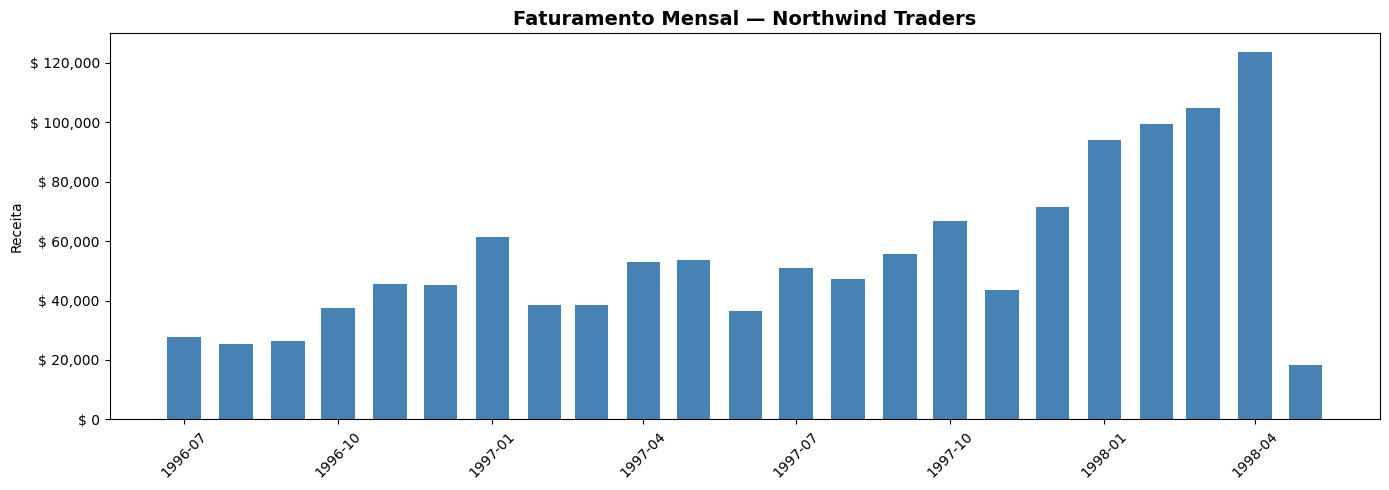

In [17]:
# 📊 Faturamento Mensal
df_rev = con.execute("""
    SELECT month, SUM(total_revenue) AS revenue
    FROM fct_revenue GROUP BY month ORDER BY month
""").df()
df_rev['month'] = pd.to_datetime(df_rev['month'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df_rev['month'], df_rev['revenue'], color='steelblue', width=20)
ax.set_title('Faturamento Mensal — Northwind Traders', fontsize=14, fontweight='bold')
ax.set_ylabel('Receita')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

churn_status  customers    revenue
       Ativo         63 1090317.70
     Churned         16  112755.63
    Em risco         10   62719.96


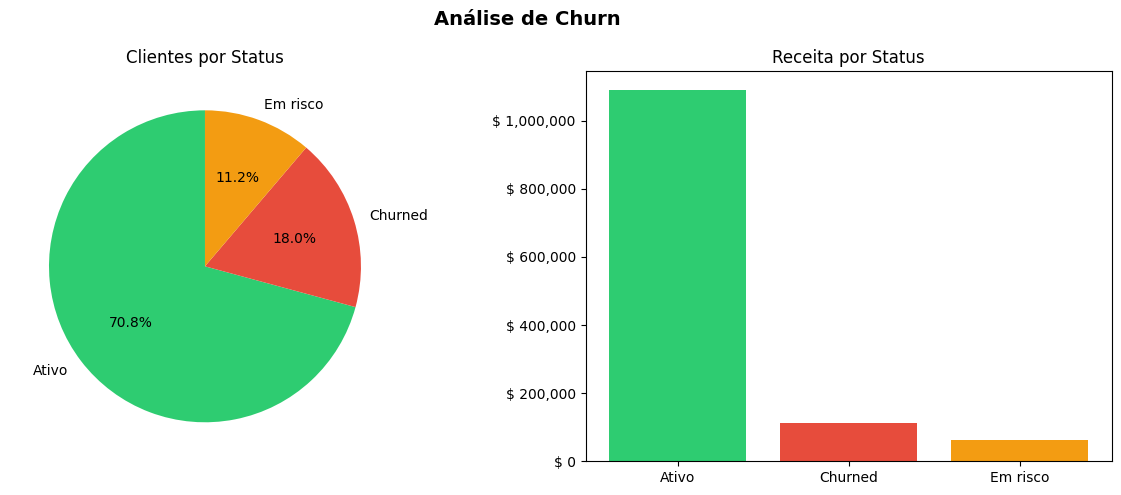

In [18]:
# 📊 Análise de Churn
df_churn = con.execute("""
    SELECT churn_status, COUNT(*) AS customers, SUM(total_revenue) AS revenue
    FROM fct_churn_analysis GROUP BY churn_status ORDER BY customers DESC
""").df()
print(df_churn.to_string(index=False))

colors_c = {'Ativo':'#2ecc71','Em risco':'#f39c12','Churned':'#e74c3c'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(df_churn['customers'], labels=df_churn['churn_status'],
            colors=[colors_c.get(s,'#888') for s in df_churn['churn_status']],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Clientes por Status')
axes[1].bar(df_churn['churn_status'], df_churn['revenue'],
            color=[colors_c.get(s,'#888') for s in df_churn['churn_status']])
axes[1].set_title('Receita por Status')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))
plt.suptitle('Análise de Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

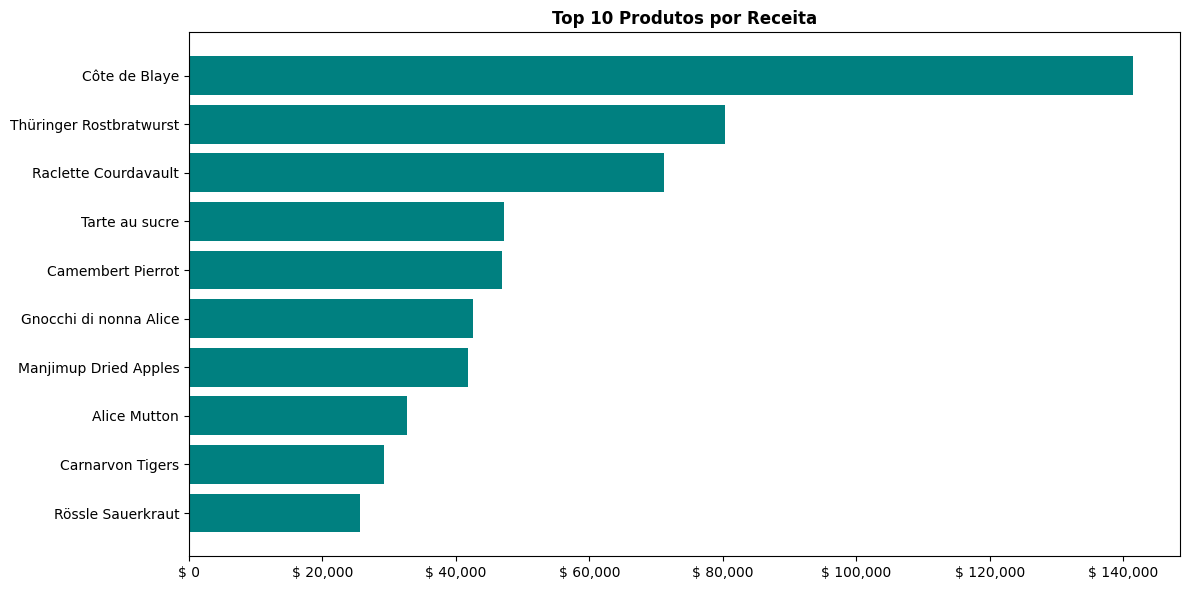

In [19]:
# 📊 Top 10 Produtos por Receita
df_prod = con.execute("""
    SELECT product_name, category_name, total_revenue
    FROM fct_top_products ORDER BY revenue_rank LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(df_prod['product_name'], df_prod['total_revenue'], color='teal')
ax.set_title('Top 10 Produtos por Receita', fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))
ax.invert_yaxis()
plt.tight_layout()
plt.show()

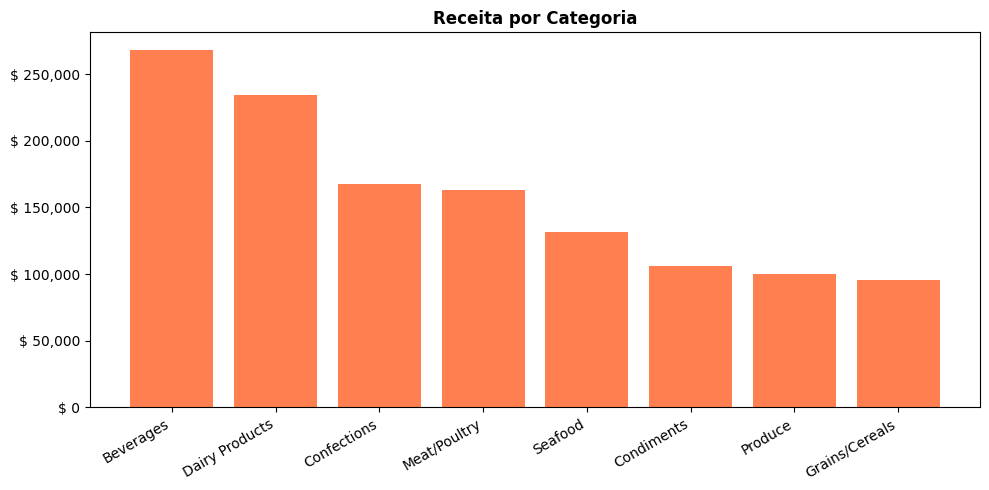

In [20]:
# 📊 Receita por Categoria
df_cat = con.execute("""
    SELECT category_name, SUM(total_revenue) AS revenue
    FROM fct_revenue_by_category GROUP BY category_name ORDER BY revenue DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_cat['category_name'], df_cat['revenue'], color='coral')
ax.set_title('Receita por Categoria', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

   employee_name  total_orders  total_revenue  avg_order_value
Margaret Peacock           156      232890.89      1492.890321
 Janet Leverling           127      202812.88      1596.951811
   Nancy Davolio           123      192107.67      1561.850976
   Andrew Fuller            96      166537.76      1734.768333
  Laura Callahan           104      126862.30      1219.829808
     Robert King            72      124568.24      1730.114444
  Anne Dodsworth            43       77308.09      1797.862558
  Michael Suyama            67       73913.15      1103.181343
 Steven Buchanan            42       68792.31      1637.912143


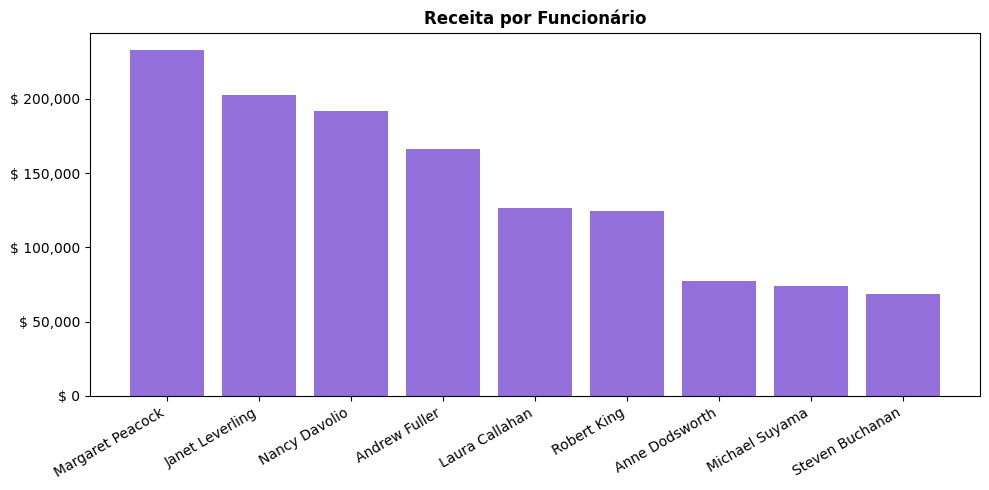

In [21]:
# 📊 Performance dos Funcionários
df_emp = con.execute("""
    SELECT employee_name, total_orders, total_revenue, avg_order_value
    FROM fct_employee_performance ORDER BY revenue_rank
""").df()
print(df_emp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_emp['employee_name'], df_emp['total_revenue'], color='mediumpurple')
ax.set_title('Receita por Funcionário', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

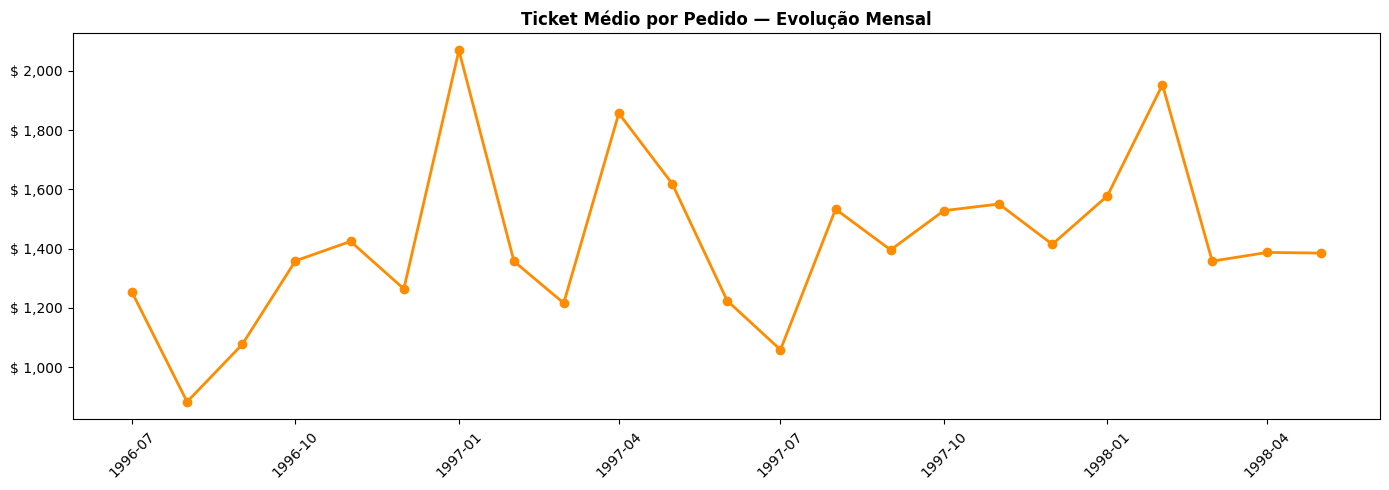

In [22]:
# 📊 Ticket Médio por Mês
df_ticket = con.execute("""
    SELECT month, AVG(ticket_medio) AS ticket_medio
    FROM fct_revenue GROUP BY month ORDER BY month
""").df()
df_ticket['month'] = pd.to_datetime(df_ticket['month'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_ticket['month'], df_ticket['ticket_medio'],
        marker='o', color='darkorange', linewidth=2)
ax.set_title('Ticket Médio por Pedido — Evolução Mensal', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 1️⃣4️⃣ Visualizar análises avançadas

rfm_segment  customers  total_revenue
    Perdido         27       871325.0
  Potencial         14       139648.0
       Leal         12       125103.0
   Champion         28        82884.0
   Em risco          8        46833.0


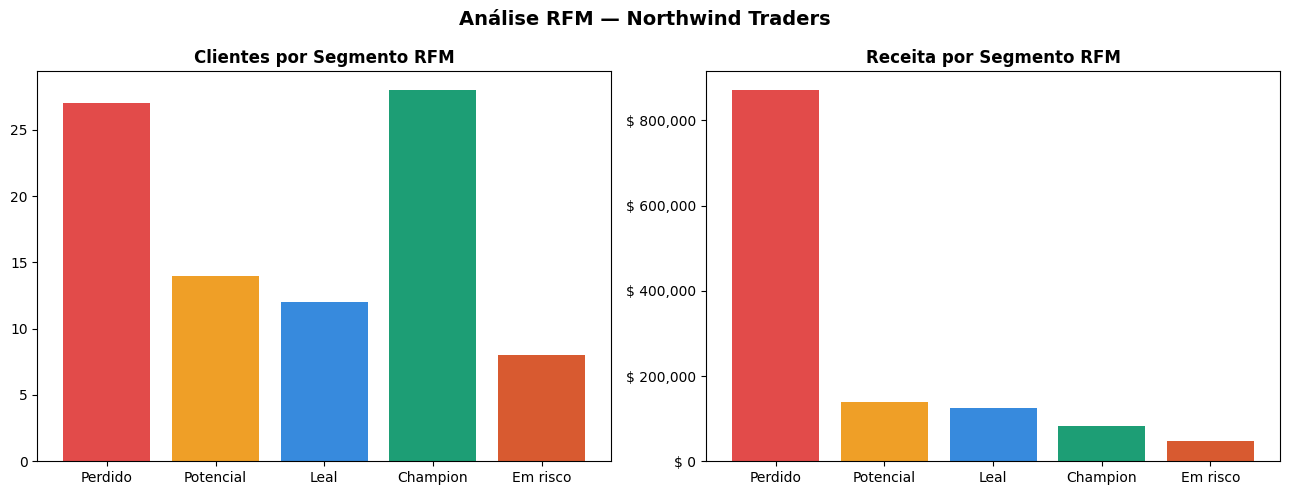

In [23]:
import seaborn as sns

# 📊 RFM (Recência, Frequência e Monetização)
df_rfm = con.execute("""
    SELECT rfm_segment, COUNT(*) AS customers,
           ROUND(SUM(monetary), 0) AS total_revenue
    FROM fct_rfm GROUP BY rfm_segment ORDER BY total_revenue DESC
""").df()
print(df_rfm.to_string(index=False))

colors_rfm = {'Champion':'#1D9E75','Leal':'#378ADD','Potencial':'#EF9F27','Em risco':'#D85A30','Perdido':'#E24B4A'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(df_rfm['rfm_segment'], df_rfm['customers'],
            color=[colors_rfm.get(s,'#888') for s in df_rfm['rfm_segment']])
axes[0].set_title('Clientes por Segmento RFM', fontweight='bold')
axes[1].bar(df_rfm['rfm_segment'], df_rfm['total_revenue'],
            color=[colors_rfm.get(s,'#888') for s in df_rfm['rfm_segment']])
axes[1].set_title('Receita por Segmento RFM', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))
plt.suptitle('Análise RFM — Northwind Traders', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

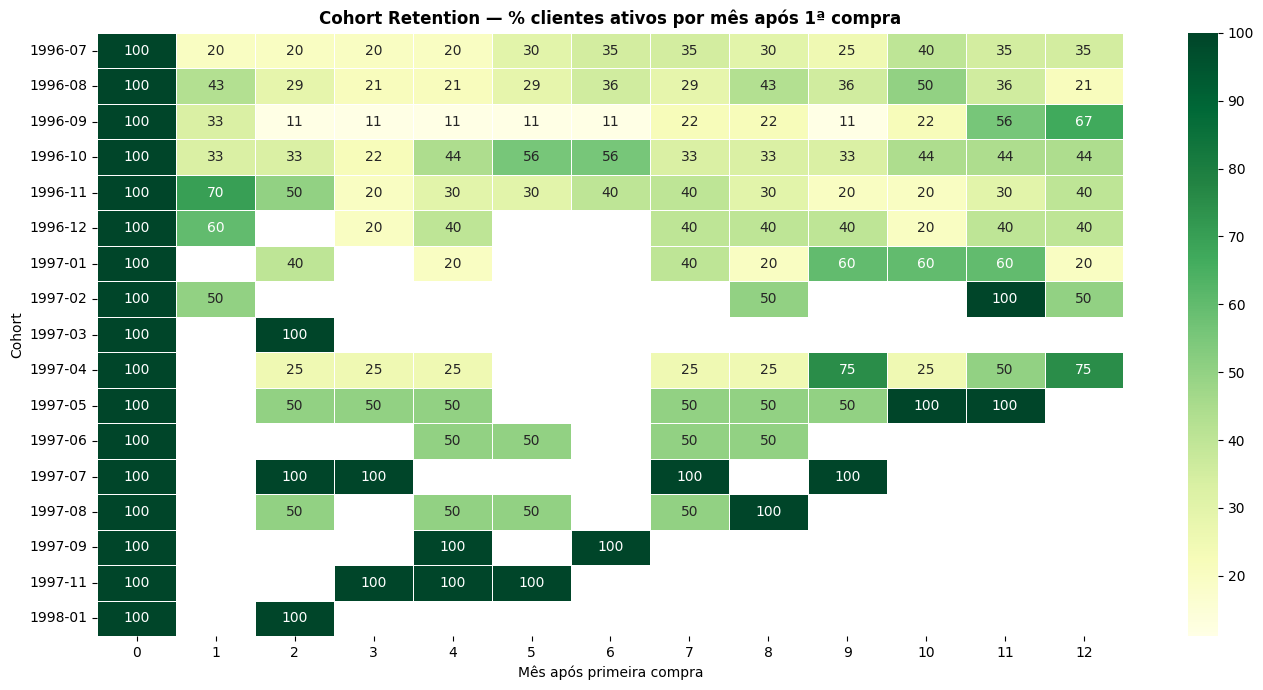

In [24]:
# 📊 Cohort Retention Heatmap
df_cohort = con.execute("""
    SELECT cohort_month, month_number, retention_rate
    FROM fct_cohort_retention WHERE month_number <= 12
    ORDER BY cohort_month, month_number
""").df()
df_cohort['cohort_month'] = pd.to_datetime(df_cohort['cohort_month']).dt.strftime('%Y-%m')
pivot = df_cohort.pivot(index='cohort_month', columns='month_number', values='retention_rate')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn', linewidths=0.5, ax=ax)
ax.set_title('Cohort Retention — % clientes ativos por mês após 1ª compra', fontweight='bold')
ax.set_xlabel('Mês após primeira compra')
ax.set_ylabel('Cohort')
plt.tight_layout()
plt.show()

    shipper_name  total_orders  late_rate_pct  avg_days_to_ship
  Speedy Express         249.0            5.3               8.8
Federal Shipping         255.0            3.7               7.4
  United Package         326.0            3.6               8.8


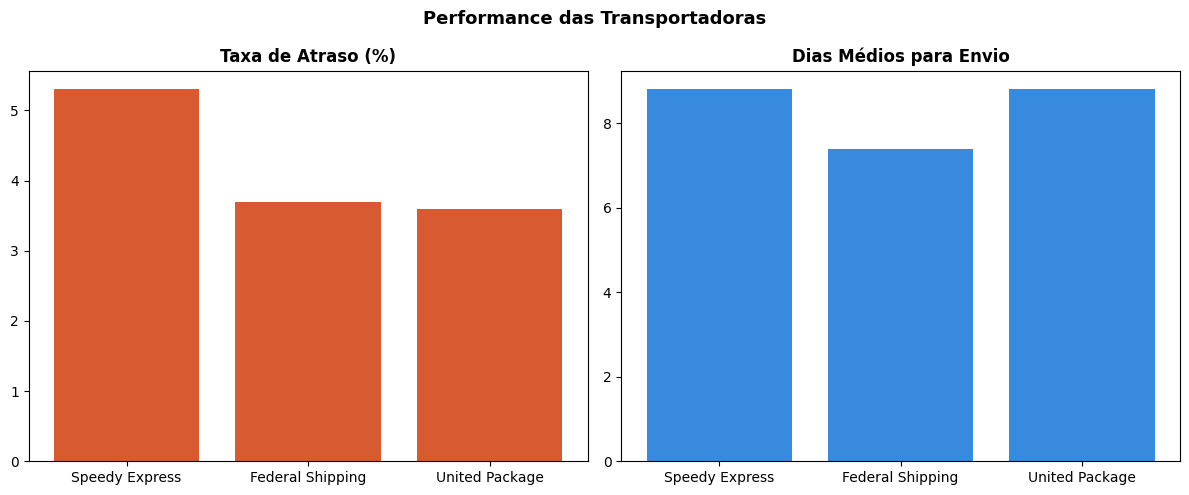

In [25]:
# 📊 SLA por Transportadora
df_sla = con.execute("""
    SELECT shipper_name,
           SUM(total_orders) AS total_orders,
           ROUND(AVG(late_rate_pct), 1) AS late_rate_pct,
           ROUND(AVG(avg_days_to_ship), 1) AS avg_days_to_ship
    FROM fct_delivery_sla WHERE shipper_name IS NOT NULL
    GROUP BY shipper_name ORDER BY late_rate_pct DESC
""").df()
print(df_sla.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(df_sla['shipper_name'], df_sla['late_rate_pct'], color='#D85A30')
axes[0].set_title('Taxa de Atraso (%)', fontweight='bold')
axes[1].bar(df_sla['shipper_name'], df_sla['avg_days_to_ship'], color='#378ADD')
axes[1].set_title('Dias Médios para Envio', fontweight='bold')
plt.suptitle('Performance das Transportadoras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

                                                     pair  times_bought_together  confidence_pct
                     Sir Rodney's Scones + Sirop d'érable                      8            20.5
                              Pavlova + Gorgonzola Telino                      7            16.3
                                 Pavlova + Tarte au sucre                      6            14.0
                          Camembert Pierrot + Flotemysost                      6            11.8
                              Pavlova + Camembert Pierrot                      6            14.0
                        Nord-Ost Matjeshering + Tourtière                      6            18.8
               Gorgonzola Telino + Mozzarella di Giovanni                      6            11.8
                                   Alice Mutton + Geitost                      5            13.5
Gnocchi di nonna Alice + Louisiana Fiery Hot Pepper Sauce                      5            10.0
                              

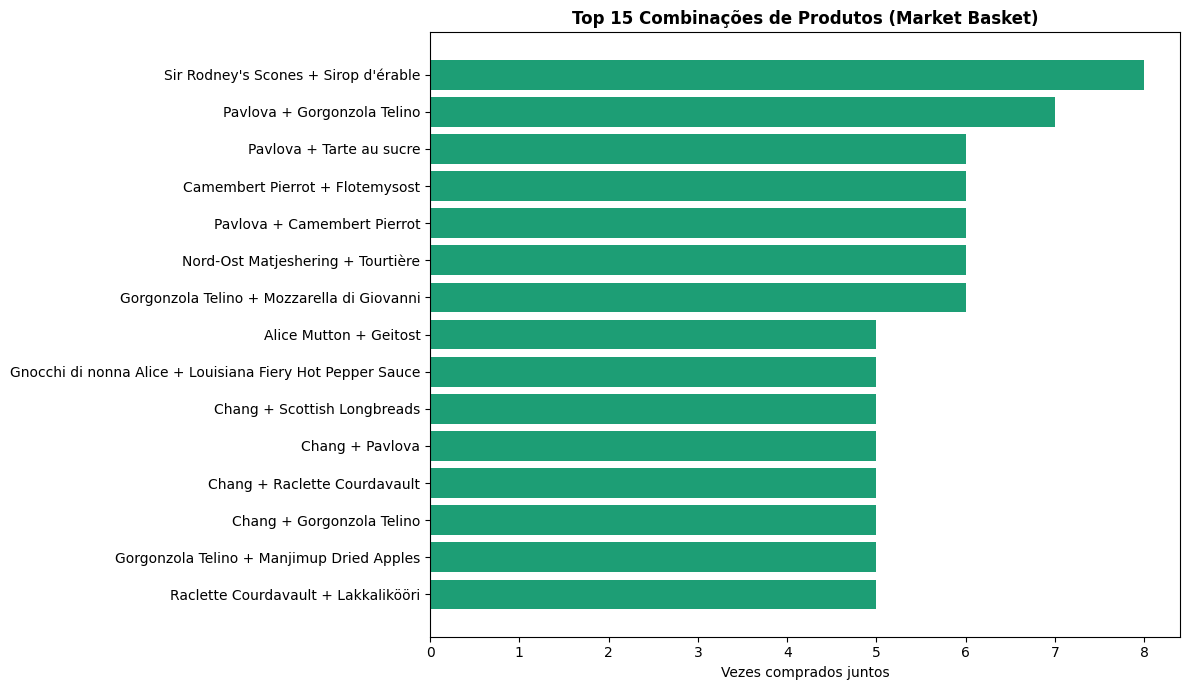

In [26]:
# 📊 Market Basket — Top 15 pares
df_mb = con.execute("""
    SELECT product_a_name || ' + ' || product_b_name AS pair,
           times_bought_together, confidence_pct
    FROM fct_market_basket ORDER BY times_bought_together DESC LIMIT 15
""").df()
print(df_mb.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_mb['pair'], df_mb['times_bought_together'], color='#1D9E75')
ax.set_title('Top 15 Combinações de Produtos (Market Basket)', fontweight='bold')
ax.set_xlabel('Vezes comprados juntos')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

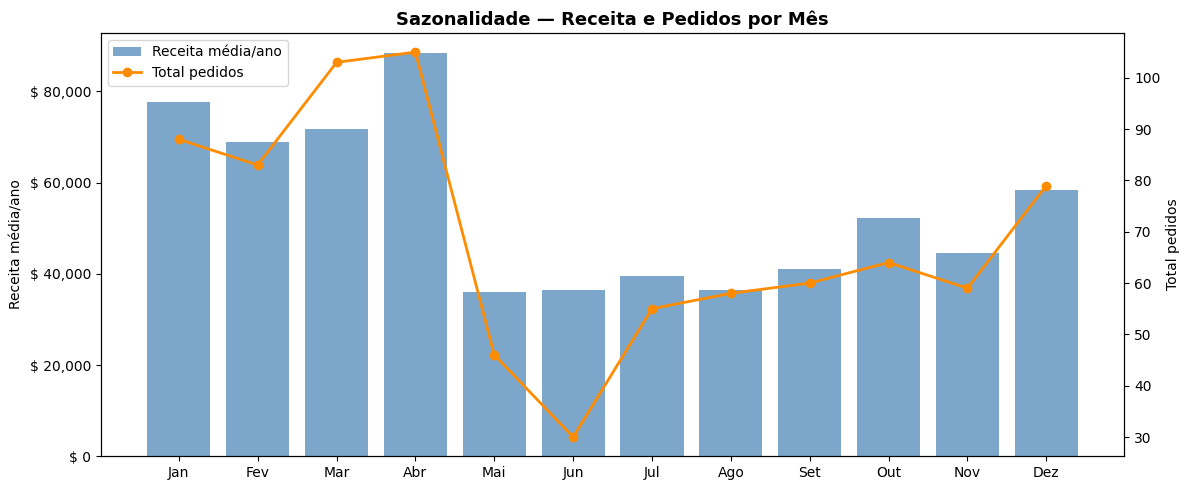

✅ Conexão DuckDB fechada


In [27]:
# 📊 Sazonalidade
df_season = con.execute("""
    SELECT month_name, month_num, avg_revenue_per_year, total_orders
    FROM fct_seasonality ORDER BY month_num
""").df()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(df_season['month_name'], df_season['avg_revenue_per_year'],
        color='steelblue', alpha=0.7, label='Receita média/ano')
ax2.plot(df_season['month_name'], df_season['total_orders'],
         color='darkorange', marker='o', linewidth=2, label='Total pedidos')
ax1.set_title('Sazonalidade — Receita e Pedidos por Mês', fontsize=13, fontweight='bold')
ax1.set_ylabel('Receita média/ano')
ax2.set_ylabel('Total pedidos')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'$ {x:,.0f}'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

con.close()
print('✅ Conexão DuckDB fechada')

In [28]:
import duckdb
con = duckdb.connect('/content/dbt_northwind.duckdb', read_only=True)

secoes = {
    "FATURAMENTO POR MÊS": """
        SELECT month, ROUND(SUM(total_revenue),0) AS revenue, SUM(num_orders) AS orders
        FROM fct_revenue GROUP BY month ORDER BY month
    """,
    "CHURN": """
        SELECT churn_status, COUNT(*) AS customers, ROUND(SUM(total_revenue),0) AS revenue
        FROM fct_churn_analysis GROUP BY churn_status
    """,
    "RFM": """
        SELECT rfm_segment, COUNT(*) AS customers, ROUND(SUM(monetary),0) AS revenue
        FROM fct_rfm GROUP BY rfm_segment ORDER BY revenue DESC
    """,
    "TOP 10 CLIENTES": """
        SELECT customer_name, customer_country, ROUND(total_revenue,0) AS revenue, revenue_rank
        FROM fct_top_customers ORDER BY revenue_rank LIMIT 10
    """,
    "TOP 10 PRODUTOS": """
        SELECT product_name, category_name, ROUND(total_revenue,0) AS revenue, total_units_sold
        FROM fct_top_products ORDER BY revenue_rank LIMIT 10
    """,
    "RECEITA POR CATEGORIA": """
        SELECT category_name, ROUND(SUM(total_revenue),0) AS revenue
        FROM fct_revenue_by_category GROUP BY category_name ORDER BY revenue DESC
    """,
    "SLA TRANSPORTADORAS": """
        SELECT shipper_name, SUM(total_orders) AS orders,
               ROUND(AVG(late_rate_pct),1) AS late_pct,
               ROUND(AVG(avg_days_to_ship),1) AS avg_days
        FROM fct_delivery_sla WHERE shipper_name IS NOT NULL
        GROUP BY shipper_name ORDER BY late_pct DESC
    """,
    "TOP 10 MARKET BASKET": """
        SELECT product_a_name, product_b_name, times_bought_together, confidence_pct
        FROM fct_market_basket ORDER BY times_bought_together DESC LIMIT 10
    """,
    "FUNCIONÁRIOS": """
        SELECT employee_name, total_orders, ROUND(total_revenue,0) AS revenue, revenue_rank
        FROM fct_employee_performance ORDER BY revenue_rank
    """,
    "SAZONALIDADE": """
        SELECT month_name, month_num, ROUND(avg_revenue_per_year,0) AS avg_revenue, total_orders
        FROM fct_seasonality ORDER BY month_num
    """,
}

for titulo, query in secoes.items():
    print(f"\n=== {titulo} ===")
    print(con.execute(query).df().to_string(index=False))


=== FATURAMENTO POR MÊS ===
     month  revenue  orders
1996-07-01  27862.0    22.0
1996-08-01  25485.0    25.0
1996-09-01  26381.0    23.0
1996-10-01  37516.0    26.0
1996-11-01  45600.0    25.0
1996-12-01  45240.0    31.0
1997-01-01  61258.0    33.0
1997-02-01  38484.0    29.0
1997-03-01  38547.0    30.0
1997-04-01  53033.0    31.0
1997-05-01  53781.0    32.0
1997-06-01  36363.0    30.0
1997-07-01  51021.0    33.0
1997-08-01  47288.0    33.0
1997-09-01  55629.0    37.0
1997-10-01  66749.0    38.0
1997-11-01  43534.0    34.0
1997-12-01  71398.0    48.0
1998-01-01  94222.0    55.0
1998-02-01  99415.0    54.0
1998-03-01 104854.0    73.0
1998-04-01 123799.0    74.0
1998-05-01  18334.0    14.0

=== CHURN ===
churn_status  customers   revenue
     Churned         16  112756.0
    Em risco         10   62720.0
       Ativo         63 1090318.0

=== RFM ===
rfm_segment  customers  revenue
    Perdido         27 871325.0
  Potencial         14 139648.0
       Leal         12 125103.0
   Cham

## 1️⃣5️⃣ Gerar documentação DBT

In [29]:
import os
os.chdir('/content/northwind')
!dbt docs generate
print('\n✅ Documentação gerada!')

14:11:37  Running with dbt=1.11.11
14:11:37  Registered adapter: duckdb=1.10.1
14:11:38  Found 27 models, 14 seeds, 18 data tests, 14 sources, 485 macros
14:11:38  
14:11:38  Concurrency: 1 threads (target='dev')
14:11:38  
14:11:38  Encountered an error:
IO Error: Could not set lock on file "/content/dbt_northwind.duckdb": Conflicting lock is held in /usr/bin/python3.12 (PID 533). However, you would be able to open this database in read-only mode, e.g. by using the -readonly parameter in the CLI. See also https://duckdb.org/docs/stable/connect/concurrency
14:11:38  Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/dbt/adapters/duckdb/connections.py", line 95, in exception_handler
    yield
  File "/usr/local/lib/python3.12/dist-packages/dbt/adapters/sql/connections.py", line 147, in add_query
    cursor = connection.handle.cursor()
             ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/dbt/adapters/contracts/connection.py", line